In [1]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('C:/Users/Acer/OneDrive/Desktop/YZ50/Week_3/names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [4]:
block_size = 3 
X, Y = [], []


for w in words[:32]:
    
    print(w)
    context = [0] * block_size
    
    for ch in w + '.':
        
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .
charlotte
... ---> c
..c ---> h
.ch ---> a
cha ---> r
har ---> l
arl ---> o
rlo ---> t
lot ---> t
ott ---> e
tte ---> .
mia
... ---> m
..m ---> i
.mi ---> a
mia ---> .
amelia
... ---> a
..a ---> m
.am ---> e
ame ---> l
mel ---> i
eli ---> a
lia ---> .
harper
... ---> h
..h ---> a
.ha ---> r
har ---> p
arp ---> e
rpe ---> r
per ---> .
evelyn
... ---> e
..e ---> v
.ev ---> e
eve ---> l
vel ---> y
ely ---> n
lyn ---> .
abigail
... ---> a
..a ---> b
.ab ---> i
abi ---> g
big ---> a
iga ---> i
gai ---> l
ail ---> .
emily
... ---> e
..e ---> m
.em ---> i
emi ---> l
mil ---> y
ily ---> .
elizabeth
... ---> e
..e ---

In [5]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0,  3,  8,  1, 18,
        12, 15, 20, 20,  5,  0, 13,  9,  1,  0,  1, 13,  5, 12,  9,  1,  0,  8,
         1, 18, 16,  5, 18,  0,  5, 22,  5, 12, 25, 14,  0,  1,  2,  9,  7,  1,
         9, 12,  0,  5, 13,  9, 12, 25,  0,  5, 12,  9, 26,  1,  2,  5, 20,  8,
         0, 13,  9, 12,  1,  0,  5, 12, 12,  1,  0,  1, 22,  5, 18, 25,  0, 19,
        15,  6,  9,  1,  0,  3,  1, 13,  9, 12,  1,  0,  1, 18,  9,  1,  0, 19,
         3,  1, 18, 12,  5, 20, 20,  0, 22,  9,  3, 20, 15, 18,  9,  1,  0, 13,
         1,  4,  9, 19, 15, 14,  0, 12, 21, 14,  1,  0,  7, 18,  1,  3,  5,  0,
         3,  8, 12, 15,  5,  0, 16,  5, 14,  5, 12, 15, 16,  5,  0, 12,  1, 25,
        12,  1,  0, 18,  9, 12,  5, 25,  0, 26, 15,  5, 25,  0, 14, 15, 18,  1,
         0, 12,  9, 12, 25,  0,  5, 12,  5,  1, 14, 15, 18,  0])

In [6]:
len(X)

212

In [7]:
C = torch.randn((27,2))
C # Aslında 2 nöronlu bir katman ve inputut da one-hot dan bir farkı yok, 3 kelimelik bir yapı için aslında ekstra 6 nöronlu bir layer demek.


tensor([[-0.7262,  0.0690],
        [ 0.3553, -0.0087],
        [-0.3365, -0.6651],
        [-0.0231,  0.6320],
        [ 0.0822, -1.1505],
        [-0.9918, -0.9965],
        [-0.6652,  1.6548],
        [ 0.4524, -0.8535],
        [ 0.0579, -1.9598],
        [ 0.5960, -1.4370],
        [ 0.2867, -0.4982],
        [ 1.3797, -1.2102],
        [-2.2363, -0.2495],
        [ 0.6677,  0.1508],
        [-0.3208, -0.8428],
        [-1.1849, -1.9633],
        [-1.0590, -2.1915],
        [ 1.6477, -1.1213],
        [ 1.5724, -0.6454],
        [ 0.2165, -0.7064],
        [-0.0964, -1.1240],
        [-1.6220, -2.0390],
        [ 0.4964,  0.9421],
        [ 2.0614, -0.7471],
        [-1.1058,  0.7306],
        [-1.1298,  0.8011],
        [-0.8027, -0.5431]])

In [8]:
emb = C[X] # 5 row 3 column ve elemanlar da 2 elemanlı
emb.shape

torch.Size([212, 3, 2])

In [9]:
torch.cat(torch.unbind(emb,1),1)

tensor([[-0.7262,  0.0690, -0.7262,  0.0690, -0.7262,  0.0690],
        [-0.7262,  0.0690, -0.7262,  0.0690, -0.9918, -0.9965],
        [-0.7262,  0.0690, -0.9918, -0.9965,  0.6677,  0.1508],
        ...,
        [-0.9918, -0.9965,  0.3553, -0.0087, -0.3208, -0.8428],
        [ 0.3553, -0.0087, -0.3208, -0.8428, -1.1849, -1.9633],
        [-0.3208, -0.8428, -1.1849, -1.9633,  1.5724, -0.6454]])

In [10]:
emb.view(-1,6)

tensor([[-0.7262,  0.0690, -0.7262,  0.0690, -0.7262,  0.0690],
        [-0.7262,  0.0690, -0.7262,  0.0690, -0.9918, -0.9965],
        [-0.7262,  0.0690, -0.9918, -0.9965,  0.6677,  0.1508],
        ...,
        [-0.9918, -0.9965,  0.3553, -0.0087, -0.3208, -0.8428],
        [ 0.3553, -0.0087, -0.3208, -0.8428, -1.1849, -1.9633],
        [-0.3208, -0.8428, -1.1849, -1.9633,  1.5724, -0.6454]])

In [11]:
g = torch.Generator().manual_seed(2147483647)

W1 = torch.randn((6,100),generator=g,requires_grad=True)
B1 = torch.rand((100),generator=g,requires_grad=True)

W1,B1

(tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
          -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
          -4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
           2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01,
           9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
           2.4968e+00,  2.4448e+00, -6.7006e-01, -1.2199e+00,  3.0314e-01,
          -1.0725e+00,  7.2762e-01,  5.1114e-02,  1.3095e+00, -8.0220e-01,
          -8.5042e-01, -1.8068e+00,  1.2523e+00, -1.2256e+00,  1.2165e+00,
          -9.6478e-01, -2.3211e-01, -3.4762e-01,  3.3244e-01, -1.3263e+00,
           1.1224e+00,  5.9641e-01,  4.5846e-01,  5.4011e-02, -1.7400e+00,
           1.1560e-01,  8.0319e-01,  5.4108e-01, -1.1646e+00,  1.4756e-01,
          -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01, -7.8305e-01,
           1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,  9.3743e-01,
          -8.8303e-01,  1

In [12]:
h = torch.tanh(emb.view(-1,6) @ W1 + B1)
h

tensor([[-0.7791, -0.6317,  0.3131,  ...,  0.9971,  0.4463,  0.5325],
        [-0.5192, -0.9700,  0.3998,  ...,  0.9998, -0.3957,  0.7979],
        [-0.8382, -0.3350,  0.2615,  ..., -0.4792,  0.9747,  0.9893],
        ...,
        [ 0.7562,  0.8726,  0.9985,  ...,  0.9880,  0.8960,  0.3255],
        [ 0.9967, -0.9988,  0.9570,  ...,  0.9991, -0.9470,  0.7771],
        [ 0.6346, -0.4851,  0.9815,  ..., -0.9421,  0.9921,  0.9999]],
       grad_fn=<TanhBackward0>)

In [13]:
W2 = torch.randn((100,27),generator=g,requires_grad=True)
B2 = torch.rand((27),generator=g,requires_grad=True)

W2,B2

(tensor([[-8.1420e-01, -6.4477e-01, -7.5282e-01,  ...,  3.4330e-01,
           2.0698e+00,  1.3405e+00],
         [-2.1746e-01,  8.6273e-01, -4.5507e-01,  ...,  3.0907e-01,
          -9.6461e-01, -1.6515e-03],
         [ 4.4576e-01,  1.6620e+00,  8.7201e-01,  ..., -1.5231e+00,
          -3.7090e-01, -1.2302e+00],
         ...,
         [ 2.2112e-01,  4.4234e-01,  1.2275e-01,  ..., -1.1457e+00,
          -8.4595e-01,  5.9320e-01],
         [-8.3251e-01, -1.4170e+00,  2.6394e-02,  ...,  3.0735e-01,
          -7.9695e-01, -1.5259e+00],
         [-2.7417e-01,  1.4247e+00, -7.6711e-01,  ...,  1.2565e+00,
           8.7425e-01, -9.9171e-01]], requires_grad=True),
 tensor([0.7538, 0.4377, 0.4034, 0.4792, 0.5614, 0.3401, 0.3721, 0.9424, 0.5452,
         0.2199, 0.9553, 0.2031, 0.5855, 0.1923, 0.2305, 0.9755, 0.8090, 0.0295,
         0.8706, 0.9043, 0.1646, 0.0413, 0.0548, 0.2155, 0.3188, 0.6351, 0.7979],
        requires_grad=True))

In [14]:
logits = h @ W2 + B2
logits

tensor([[ -0.5676,   0.9752,   8.0186,  ...,   0.2170,  -2.9217,  -9.4090],
        [ -6.0833,  -4.4796,  10.1472,  ...,   1.4966,   0.4954, -10.2704],
        [  0.2271,  10.1725,  13.3505,  ...,   4.9458,   6.8681, -12.2449],
        ...,
        [  2.7963,   9.8185,   7.3583,  ...,   0.7332,   2.1980,  -7.8570],
        [  3.4113,  -3.4959,   2.2321,  ...,  -7.6424,  -4.7281, -11.7641],
        [ -0.6553,   4.9599,   8.8032,  ...,   4.0115,   2.0282, -18.1771]],
       grad_fn=<AddBackward0>)

In [15]:
counts = logits.exp()
probs = counts / counts.sum(1,keepdim=True)
len(probs[0])

27

In [16]:
Y[84]

tensor(26)

In [17]:
out = []
for i in range(len(Y)):
    out.append(probs[i,Y[i]].item())
    print(i)
out

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211


[1.4865704500710564e-10,
 1.5037468159562195e-08,
 1.6530232518625725e-14,
 0.8835494518280029,
 5.115771273267455e-07,
 0.9805423617362976,
 4.007311531495361e-07,
 2.040873070541238e-08,
 5.384201813285472e-06,
 4.296059952224596e-09,
 1.1529887045114151e-09,
 2.0546710999269635e-08,
 5.720516060847558e-09,
 3.1888970397631056e-07,
 0.9994003772735596,
 9.211343154902352e-08,
 6.900939979459508e-07,
 9.381738719227428e-10,
 4.3978056964988355e-06,
 4.667081721088095e-10,
 0.0037408575881272554,
 0.003938423469662666,
 0.00024535940610803664,
 2.869391447943249e-15,
 1.6736294128349982e-08,
 1.4291380443431576e-14,
 0.013124820776283741,
 5.415543688269469e-15,
 2.897121476053144e-08,
 1.6268305591538024e-09,
 4.095185795449652e-05,
 9.061771561391652e-05,
 7.227528158182395e-07,
 5.174897523829713e-07,
 1.7098239490920264e-10,
 6.635191880377533e-07,
 2.4290373992806938e-14,
 0.03463146463036537,
 7.258563194945111e-10,
 8.43178405243207e-14,
 6.198667534818014e-08,
 9.83534391707507

In [18]:
out = probs[torch.arange(len(Y)),Y]
loss = -torch.log(out).mean()
loss

tensor(17.2352, grad_fn=<NegBackward0>)

In [43]:
# Backpropagation
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn((6,100),generator=g,requires_grad=True)
B1 = torch.rand((100),generator=g,requires_grad=True)
W2 = torch.randn((100,27),generator=g,requires_grad=True)
B2 = torch.rand((27),generator=g,requires_grad=True)

parameters = [W1,B1,W2,B2]


#print(f'W1: {W1.data[0,0]}, W2: {W2.data[0,0]}, B1: {B1.data[0]}, B2: {B2.data[0]}')


In [44]:
lre = torch.linspace(-3,0,1000)
lre = 10**lre
lr = lre[1]
lr

tensor(0.0010)

In [45]:
lri = []
lossi = []

for i in range(1000):
    
    ix = torch.randint(0,X.shape[0],(32,))
    emb = C[X[ix]]
    
    h = torch.tanh(emb.view(-1,6) @ W1 + B1)
    logits = h @ W2 + B2
    loss = f.cross_entropy(logits,Y[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = lre[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    lri.append(lr)
    lossi.append(loss.item())
    
    #print(f'Learning Rate = {i}: loss = {loss.item()}')

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

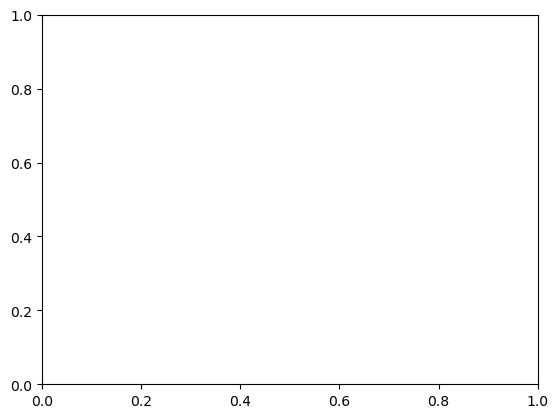

In [46]:
plt.plot(lri,loss)